In [ ]:
!pip install rawpy imageio pandas openpyxl scipy matplotlib numpy

   ---------------------------------------- 0.0/921.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/921.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/921.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/921.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/921.4 kB ? eta -:--:--
   --------------------- ---------------- 524.3/921.4 kB 155.


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


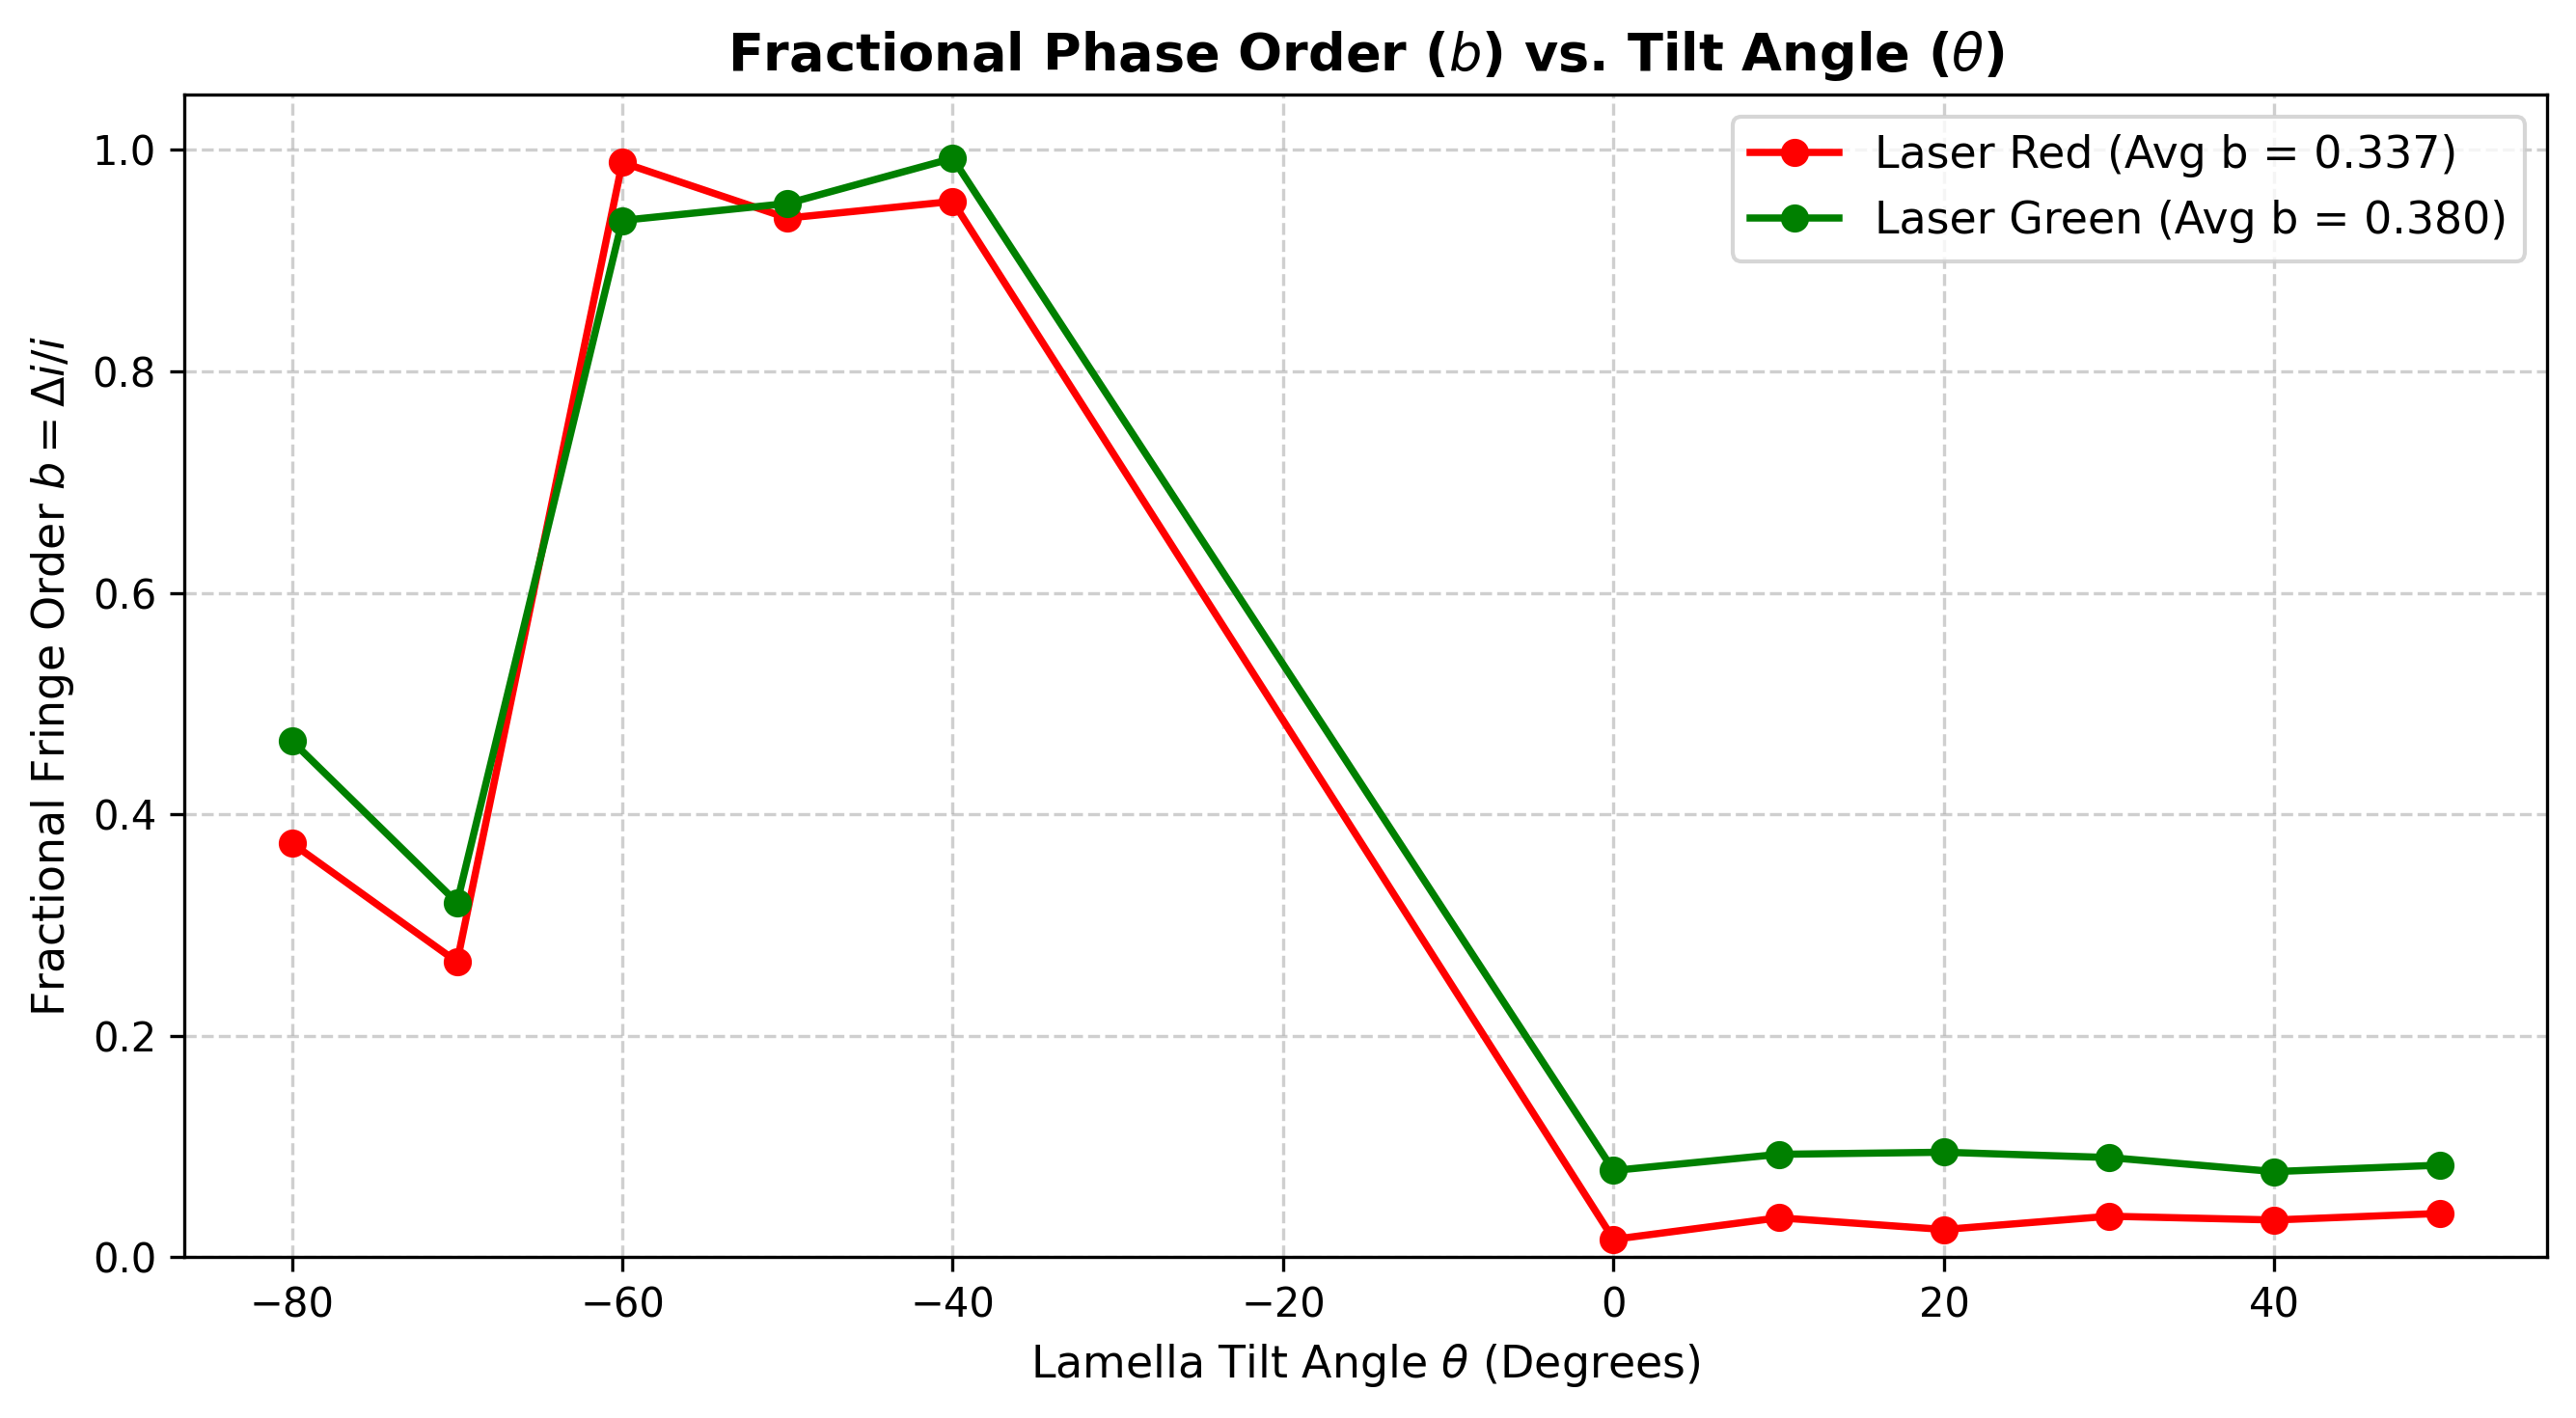


            Final results of dual-wavelength minimization
First wavelength (Red): 632.8 nm  | Average fractional b = 0.3370
Second wavelength (Green): 532.0 nm  | Average fractional b = 0.3802
-------------------------------------------------------
Integer interference order Red (N_Red): 496
Integer interference order Green (N_Green): 590
-------------------------------------------------------
Optimal numerical lamella thickness (L):
  --> 157041.14 nm
  --> 157.0411 µm (micrometers)



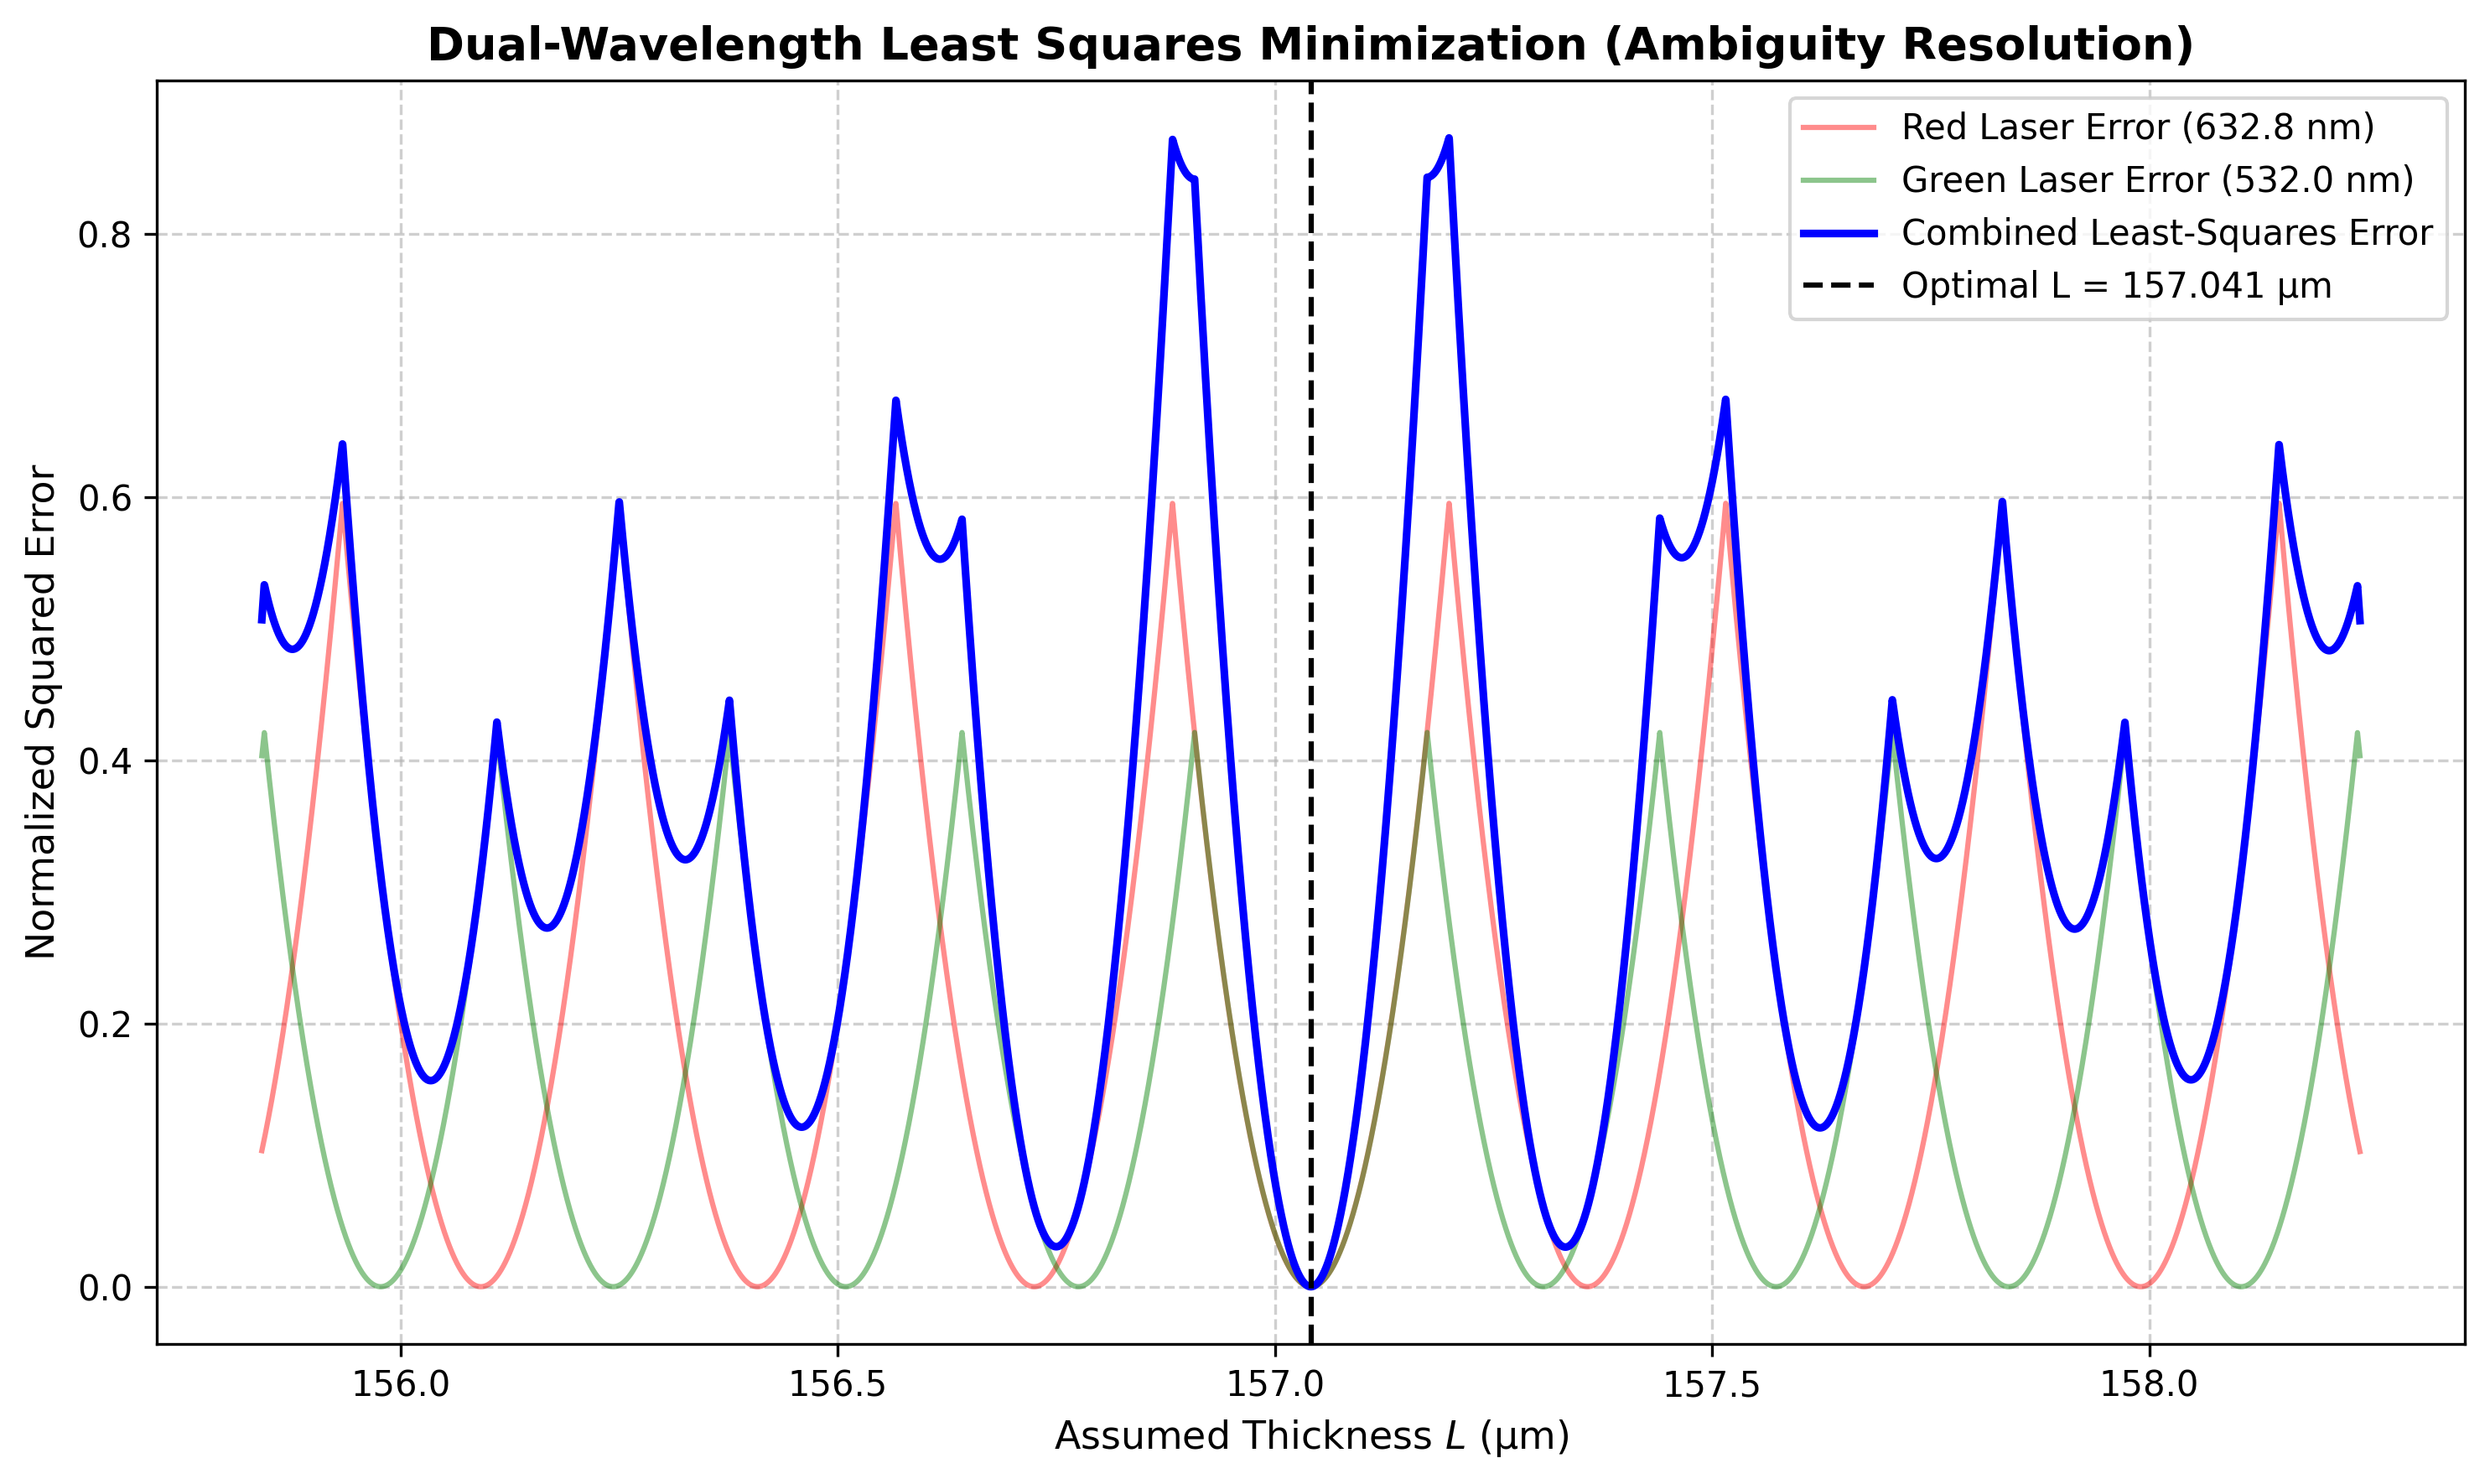

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Initial settings and reading the Excel file
# ==========================================
folder_path = r'C:\Users\Lenovo\Downloads'
excel_file = os.path.join(folder_path, 'Book1_cleaned.xlsx')

if not os.path.exists(excel_file):
    excel_file = os.path.join(folder_path, 'Book1_cleaned.csv')
    df = pd.read_csv(excel_file)
else:
    df = pd.read_excel(excel_file)

# Standardize column names
df.columns = [c.strip() for c in df.columns]
col_theta = 'theta'
col_b = 'Fractional b'
col_color = 'color'

# Convert data to numeric type
df[col_theta] = pd.to_numeric(df[col_theta], errors='coerce')
df[col_b] = pd.to_numeric(df[col_b], errors='coerce')
df[col_color] = df[col_color].astype(str).str.strip().str.capitalize()

# Reference wavelengths in nanometers
WAVELENGTHS = {
    'Red': 632.8,
    'Green': 532.0,
    'Blue': 405.0
}

# ==========================================
# Variation of b versus angle theta
# ==========================================
plt.figure(figsize=(9, 5), dpi=300)
colors_in_df = df[col_color].unique()

color_map_plot = {'Red': 'red', 'Green': 'green', 'Blue': 'blue'}

for c in colors_in_df:
    sub_df = df[df[col_color] == c].sort_values(by=col_theta)
    if not sub_df.empty:
        plt.plot(sub_df[col_theta], sub_df[col_b], marker='o', linestyle='-',
                 linewidth=1.8, markersize=6,
                 color=color_map_plot.get(c, 'black'),
                 label=f'Laser {c} (Avg b = {sub_df[col_b].mean():.3f})')

plt.title(r'Fractional Phase Order ($b$) vs. Tilt Angle ($\theta$)', fontsize=13, fontweight='bold')
plt.xlabel(r'Lamella Tilt Angle $\theta$ (Degrees)', fontsize=11)
plt.ylabel(r'Fractional Fringe Order $b = \Delta i / i$', fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('Figure_1_Fractional_b_vs_Theta.png', dpi=300)
plt.show()

# ==========================================
# Dual-wavelength minimization algorithm around L = 155 um
# ==========================================
active_colors = [c for c in ['Red', 'Green', 'Blue'] if c in colors_in_df]
if len(active_colors) < 2:
    raise ValueError("At least two colors are required to run the combined method.")

c1, c2 = active_colors[0], active_colors[1]
lambda1, lambda2 = WAVELENGTHS[c1], WAVELENGTHS[c2]

b1 = df[df[col_color] == c1][col_b].mean()
b2 = df[df[col_color] == c2][col_b].mean()

# Hypothetical search range for thickness L around 155 micrometers (150 to 160 micrometers)
L_target_um = 155.0
L_min_nm = (L_target_um - 5.0) * 1000.0  # 150 um -> nm
L_max_nm = (L_target_um + 5.0) * 1000.0  # 160 um -> nm

L_test = np.linspace(L_min_nm, L_max_nm, 50000)

error1 = np.zeros_like(L_test)
error2 = np.zeros_like(L_test)
error_Total = np.zeros_like(L_test)

for idx, L in enumerate(L_test):
    # Calculate the hypothetical integer interference order at each point
    N1 = round((2.0 * L / lambda1) - b1)
    N2 = round((2.0 * L / lambda2) - b2)

    e1 = (2.0 * L - (N1 + b1) * lambda1)**2
    e2 = (2.0 * L - (N2 + b2) * lambda2)**2

    error1[idx] = e1
    error2[idx] = e2
    error_Total[idx] = e1 + e2

# Normalize for better comparison
norm_factor = np.max(error_Total)
error1 /= norm_factor
error2 /= norm_factor
error_Total /= norm_factor

# Find the absolute minimum
min_index = np.argmin(error_Total)
best_L_nm = L_test[min_index]
best_L_um = best_L_nm / 1000.0

best_N1 = round((2.0 * best_L_nm / lambda1) - b1)
best_N2 = round((2.0 * best_L_nm / lambda2) - b2)

# ==========================================
# Print computational outputs
# ==========================================
print("\n" + "="*55)
print("            Final results of dual-wavelength minimization")
print("="*55)
print(f"First wavelength ({c1}): {lambda1} nm  | Average fractional b = {b1:.4f}")
print(f"Second wavelength ({c2}): {lambda2} nm  | Average fractional b = {b2:.4f}")
print("-" * 55)
print(f"Integer interference order {c1} (N_{c1}): {best_N1}")
print(f"Integer interference order {c2} (N_{c2}): {best_N2}")
print("-" * 55)
print(f"Optimal numerical lamella thickness (L):")
print(f"  --> {best_L_nm:.2f} nm")
print(f"  --> {best_L_um:.4f} µm (micrometers)")
print("="*55 + "\n")

# ==========================================
# Error function minimization
# ==========================================
plt.figure(figsize=(10, 6), dpi=300)
zoom_range = (L_test >= (best_L_nm - 1200)) & (L_test <= (best_L_nm + 1200))

plt.plot(L_test[zoom_range] / 1000.0, error1[zoom_range],
         color=color_map_plot.get(c1, 'red'), alpha=0.45,
         label=f'{c1} Laser Error ({lambda1} nm)')

plt.plot(L_test[zoom_range] / 1000.0, error2[zoom_range],
         color=color_map_plot.get(c2, 'green'), alpha=0.45,
         label=f'{c2} Laser Error ({lambda2} nm)')

plt.plot(L_test[zoom_range] / 1000.0, error_Total[zoom_range],
         color='blue', linewidth=2.2,
         label='Combined Least-Squares Error')

plt.axvline(x=best_L_um, color='black', linestyle='--', linewidth=1.5,
            label=f'Optimal L = {best_L_um:.3f} µm')

plt.title('Dual-Wavelength Least Squares Minimization (Ambiguity Resolution)', fontsize=13, fontweight='bold')
plt.xlabel(r'Assumed Thickness $L$ (µm)', fontsize=11)
plt.ylabel('Normalized Squared Error', fontsize=11)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Figure_2_Dual_Wavelength_Minimization.png', dpi=300)
plt.show()

<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
<>:133: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1301/3326406028.py:133: SyntaxWarning: invalid escape sequence '\l'
  ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],
/tmp/ipykernel_1301/3326406028.py:133: SyntaxWarning: invalid escape sequence '\l'
  ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],



     بودجه عدم قطعیت ترکیبی دو طول‌موجی برای ضخامت لامل (L = 157.0411 µm)
                  Source Sensitivity (c_i) Contribution u_i(L) [nm] Variance Share (%)
  Red Fringe Phase (f_R)            158.16                    2.372             46.97%
Green Fringe Phase (f_G)            132.96                    1.994             33.20%
    Red Wavelength (λ_R)            124.08                    0.620              3.21%
  Green Wavelength (λ_G)            147.60                    0.738              4.55%
Alignment & Cosine Error              1.00                    1.200             12.02%
Air Refractive Index (n)         156998.71                    0.078              0.05%
------------------------------------------------------------------------------
عدم قطعیت مرکب استاندارد (u_c): 3.461 nm  (0.00346 µm)
عدم قطعیت گسترده (U, k=2):      6.923 nm  (0.00692 µm)
نتیجه نهایی گزارش: L = (157.0411 ± 0.0069) µm



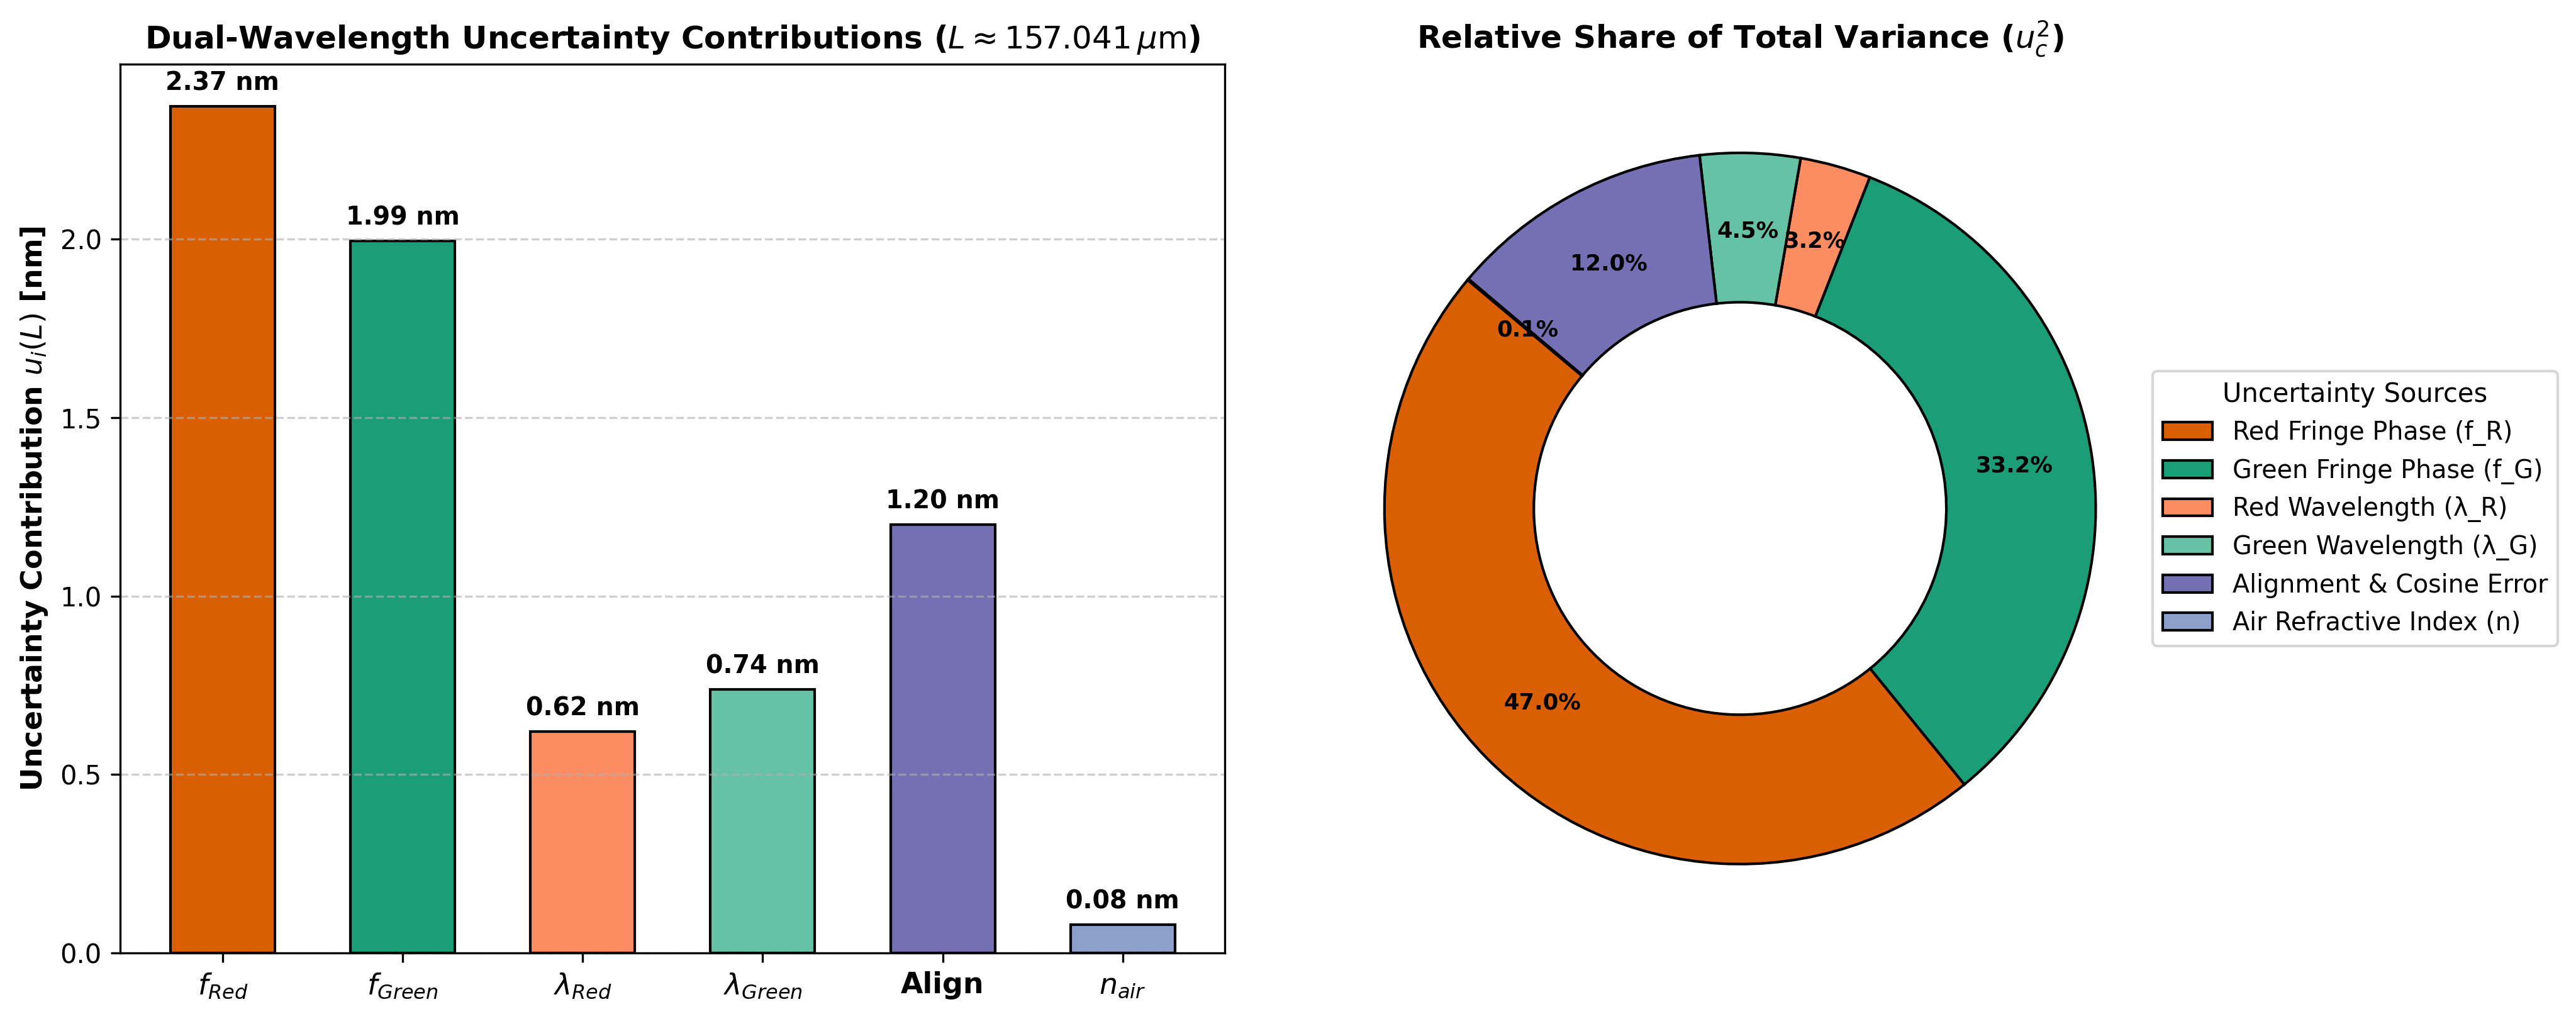

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ========================================================
# Laboratory parameters for both wavelengths
# ========================================================
L_um = 157.0411
L_nm = L_um * 1000.0
n_air = 1.00027

# Red light specifications
lambda_R = 632.8  # nm
N_R = 496
b_R = 0.3370
u_f_R = 0.015  # uncertainty of red fringe fraction
u_lambda_R = 0.005  # uncertainty of red wavelength (nm)

# Green light specifications
lambda_G = 532.0  # nm
N_G = 590
b_G = 0.3802
u_f_G = 0.015  # uncertainty of green fringe fraction
u_lambda_G = 0.005  # uncertainty of green wavelength (nm)

# Environmental and mechanical conditions
u_n = 5.0e-7  # uncertainty of air refractive index
u_align = 1.20  # uncertainty of alignment and cosine error (nm)

# ========================================================
# Analytical sensitivity coefficients (partial derivatives dL/dx_i)
# Based on the analytical model: L = (L_Red + L_Green) / 2
# ========================================================
c_f_R = lambda_R / (4.0 * n_air)
c_f_G = lambda_G / (4.0 * n_air)

c_lambda_R = L_nm / (2.0 * lambda_R)
c_lambda_G = L_nm / (2.0 * lambda_G)

c_n = L_nm / n_air

# ========================================================
# Calculate the uncertainty contribution of each component (in nanometers)
# ========================================================
u_L_f_R = c_f_R * u_f_R  # red fringe fraction contribution
u_L_f_G = c_f_G * u_f_G  # green fringe fraction contribution
u_L_lam_R = c_lambda_R * u_lambda_R  # red wavelength contribution
u_L_lam_G = c_lambda_G * u_lambda_G  # green wavelength contribution
u_L_n = c_n * u_n  # air refractive index contribution
u_L_align = u_align  # alignment error contribution

labels = [
    'Red Fringe Phase (f_R)',
    'Green Fringe Phase (f_G)',
    'Red Wavelength (λ_R)',
    'Green Wavelength (λ_G)',
    'Alignment & Cosine Error',
    'Air Refractive Index (n)',
]

u_contributions = [
    u_L_f_R,
    u_L_f_G,
    u_L_lam_R,
    u_L_lam_G,
    u_L_align,
    u_L_n,
]
variances = [u**2 for u in u_contributions]

# Combined standard uncertainty (u_c)
u_c_nm = np.sqrt(sum(variances))
u_c_um = u_c_nm / 1000.0

# Expanded uncertainty (k=2 -> 95% confidence level)
U_expanded_nm = 2.0 * u_c_nm
U_expanded_um = U_expanded_nm / 1000.0

percent_shares = [(v / sum(variances)) * 100.0 for v in variances]




df_budget = pd.DataFrame(
    {
        'Source': labels,
        'Sensitivity (c_i)': [
            f'{c_f_R:.2f}',
            f'{c_f_G:.2f}',
            f'{c_lambda_R:.2f}',
            f'{c_lambda_G:.2f}',
            '1.00',
            f'{c_n:.2f}',
        ],
        'Contribution u_i(L) [nm]': [f'{u:.3f}' for u in u_contributions],
        'Variance Share (%)': [f'{p:.2f}%' for p in percent_shares],
    }
)

print("\n" + "=" * 78)
print(
    f"     Combined dual-wavelength uncertainty budget for lamella thickness (L = {L_um:.4f} µm)"
)
print("=" * 78)
print(df_budget.to_string(index=False))
print("-" * 78)
print(
    f"Combined standard uncertainty (u_c): {u_c_nm:.3f} nm  ({u_c_um:.5f} µm)"
)
print(
    f"Expanded uncertainty (U, k=2):      {U_expanded_nm:.3f} nm  ({U_expanded_um:.5f} µm)"
)
print(f"Final reported result: L = ({L_um:.4f} ± {U_expanded_um:.4f}) µm")
print("=" * 78 + "\n")



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

plot_colors = ['#d95f02', '#1b9e77', '#fc8d62', '#66c2a5', '#7570b3', '#8da0cb']

bars = ax1.bar(
    range(len(labels)),
    u_contributions,
    color=plot_colors,
    edgecolor='black',
    width=0.58,
)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(
    ['$f_{Red}$', '$f_{Green}$', '$\lambda_{Red}$', '$\lambda_{Green}$', 'Align', '$n_{air}$'],
    fontsize=11,
    fontweight='bold',
)
ax1.set_ylabel(
    'Uncertainty Contribution $u_i(L)$ [nm]', fontsize=11, fontweight='bold'
)
ax1.set_title(
    r'Dual-Wavelength Uncertainty Contributions ($L \approx 157.041\,\mu\mathrm{m}$)',
    fontsize=12,
    fontweight='bold',
)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    h = bar.get_height()
    ax1.annotate(
        f'{h:.2f} nm',
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9.5,
        fontweight='bold',
    )


wedges, texts, autotexts = ax2.pie(
    variances,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.78,
    colors=plot_colors,
    startangle=140,
    wedgeprops=dict(width=0.42, edgecolor='black'),
)
for at in autotexts:
    at.set_color('black')
    at.set_fontsize(8.5)
    at.set_fontweight('bold')

ax2.legend(
    wedges,
    labels,
    title='Uncertainty Sources',
    loc='center left',
    bbox_to_anchor=(0.95, 0.5),
    fontsize=9.5,
)
ax2.set_title(
    'Relative Share of Total Variance ($u_c^2$)', fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'Figure_5_1_Dual_Wavelength_Uncertainty_Budget.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()